In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Adjust the filename to match your file in data/
df = pd.read_csv(r'C:\Users\unhac\Downloads\all_bikez_curated.csv.zip')
df.head()

C:\Users\unhac\AppData\Local\Temp\ipykernel_2148\917918535.py:7: DtypeWarning: Columns (0: Stroke (mm)) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'C:\Users\unhac\Downloads\all_bikez_curated.csv.zip')


,Brand,Model,Year,Category,Rating,Displacement (ccm),Power (hp),Torque (Nm),Engine cylinder,Engine stroke,...,Dry weight (kg),Wheelbase (mm),Seat height (mm),Front brakes,Rear brakes,Front tire,Rear tire,Front suspension,Rear suspension,Color options
0,acabion,da vinci 650-vi,2011,Prototype / concept model,3.2,NaN,804.0,NaN,Electric,Electric,...,420.0,NaN,NaN,Single disc,Single disc,NaN,NaN,NaN,NaN,NaN
1,acabion,gtbo 55,2007,Sport,2.6,1300.0,541.0,420.0,In-line four,four-stroke,...,360.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,acabion,gtbo 600 daytona-vi,2011,Prototype / concept model,3.5,NaN,536.0,NaN,Electric,Electric,...,420.0,NaN,NaN,Single disc,Single disc,NaN,NaN,NaN,NaN,NaN
3,acabion,gtbo 600 daytona-vi,2021,Prototype / concept model,NaN,NaN,536.0,NaN,Electric,Electric,...,420.0,NaN,NaN,Single disc,Single disc,NaN,NaN,NaN,NaN,NaN
4,acabion,gtbo 70,2007,Prototype / concept model,3.1,1300.0,689.0,490.0,In-line four,four-stroke,...,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Custom made.


In [8]:
print("Shape:", df.shape)
print("Data Types:\n", df.dtypes)
print("Missing Values:\n", df.isnull().sum())

Shape: (38472, 28)
Data Types:
 Brand                      str
Model                      str
Year                     int64
Category                   str
Rating                 float64
Displacement (ccm)     float64
Power (hp)             float64
Torque (Nm)            float64
Engine cylinder            str
Engine stroke              str
Gearbox                    str
Bore (mm)              float64
Stroke (mm)             object
Fuel capacity (lts)    float64
Fuel system                str
Fuel control               str
Cooling system             str
Transmission type          str
Dry weight (kg)        float64
Wheelbase (mm)         float64
Seat height (mm)       float64
Front brakes               str
Rear brakes                str
Front tire                 str
Rear tire                  str
Front suspension           str
Rear suspension            str
Color options              str
dtype: object
Missing Values:
 Brand                      0
Model                     28
Year       

In [9]:
target_col = 'Power (hp)'
print(df[target_col].describe())
print("Missing values in target:", df[target_col].isnull().sum())

count    26110.000000
mean        50.776040
std         52.082094
min          0.300000
25%         12.000000
50%         30.000000
75%         77.000000
max        804.000000
Name: Power (hp), dtype: float64
Missing values in target: 12362


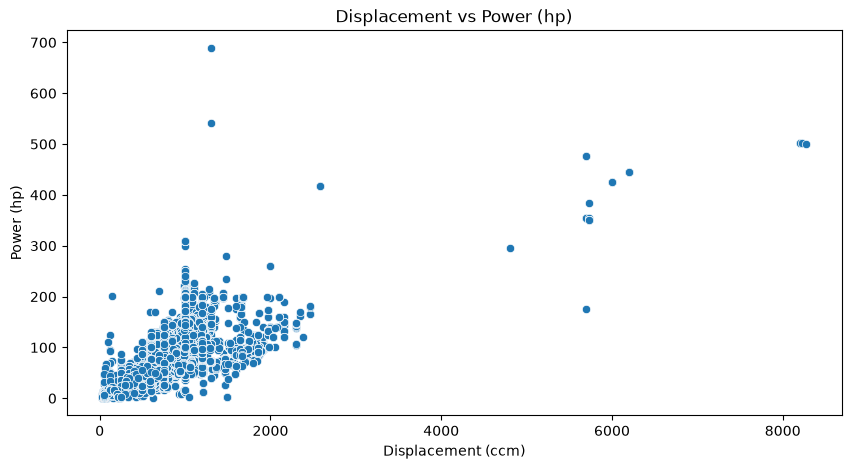

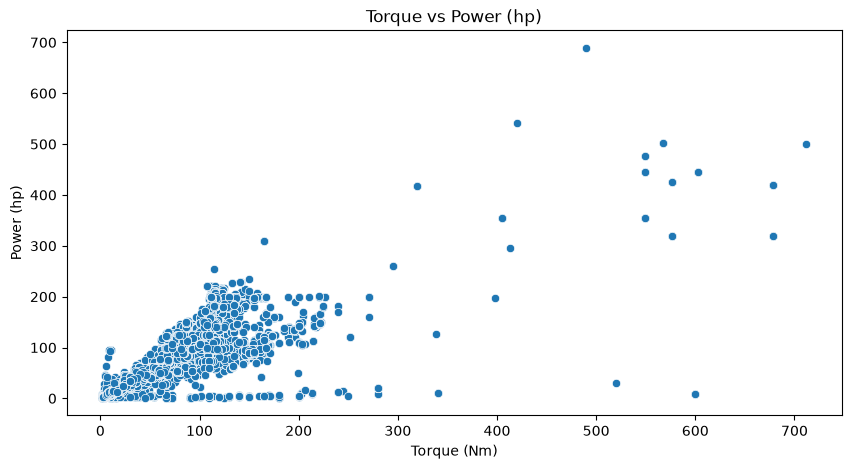

In [10]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Displacement (ccm)', y='Power (hp)')
plt.title('Displacement vs Power (hp)')
plt.show()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='Torque (Nm)', y='Power (hp)')
plt.title('Torque vs Power (hp)')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop categorical columns for now or encode them; using only numeric for baseline
numeric_df = df.select_dtypes(include=['float64', 'int64']).dropna()
X = numeric_df.drop(columns=['Power (hp)'])
y = numeric_df['Power (hp)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "ElasticNet": ElasticNet(),
    "Polynomial": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    results.append([name, r2, rmse, mae])

results_df = pd.DataFrame(results, columns=['Model', 'R2', 'RMSE', 'MAE'])
results_df = results_df.sort_values(by='R2', ascending=False)
display(results_df)

,Model,R2,RMSE,MAE
6,Random Forest,0.942550,12.843250,3.844548
5,Decision Tree,0.937295,13.417796,3.491597
7,Gradient Boosting,0.929979,14.179000,6.815696
9,KNN,0.895563,17.316456,8.513810
4,Polynomial,0.888962,17.855292,9.551727
1,Ridge Regression,0.839765,21.449161,14.059337
0,Linear Regression,0.838685,21.521271,14.029662
2,Lasso Regression,0.835412,21.738527,16.269534
8,SVR,0.768403,25.786828,14.530503
3,ElasticNet,0.702160,29.243040,21.920691
